<a href="https://colab.research.google.com/github/chenj209/nncam_training/blob/master/models/mnist_test_em_version.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import numpy as np

In [3]:
# class Encoder(nn.Module):
#     def __init__(self, config):
#         super(Encoder, self).__init__()
#         input_size = config["input_size"]
#         channel_sizes = config["channel_sizes"]
#         kernel_size = config["kernel_size"]
#         strides = config["stride"]
#         paddings = config["padding"]
#         output_paddings = config["output_padding"]

#         conv_layers = [
#             nn.Conv2d(input_size[0], channel_sizes[0], kernel_size=kernel_size, stride=strides[0], padding=paddings[0]),
#             nn.BatchNorm2d(channel_sizes[0]),
#             nn.ReLU(True)
#         ]
#         for i in range(len(channel_sizes)-1):
#             conv_layers.extend([
#                 nn.Conv2d(channel_sizes[i], channel_sizes[i+1], kernel_size=kernel_size, stride=strides[i+1], padding=paddings[i+1]),
#                 nn.BatchNorm2d(channel_sizes[i+1]),
#                 nn.ReLU(True),
#             ])
#         self.conv = nn.Sequential(*conv_layers)

#         self.flatten = nn.Flatten(start_dim=1)

#         h = input_size[1]
#         w = input_size[2]
#         for i in range(len(channel_sizes)):
#             h = np.floor((h - kernel_size + 2 * paddings[i]) / strides[i]) + 1
#             w = np.floor((w - kernel_size + 2 * paddings[i]) / strides[i]) + 1
#         self.flattened_size = int(channel_sizes[-1] * h * w)

#         self.fc = nn.Linear(self.flattened_size, config["latent_size"])

#     def forward(self, x):
#         # print(x.shape)
#         x = self.conv(x)
#         x = self.flatten(x)
#         x = self.fc(x)
#         return x

# # write a correspoinding decoder
# class Decoder(nn.Module):
#     def __init__(self, config):
#         super(Decoder, self).__init__()
#         input_size = config["input_size"]
#         channel_sizes = config["channel_sizes"][::-1]
#         kernel_size = config["kernel_size"]
#         strides = config["stride"][::-1]
#         paddings = config["padding"][::-1]
#         output_paddings = config["output_padding"][::-1]

#         h = input_size[1]
#         w = input_size[2]
#         for i in range(len(channel_sizes)):
#             h = np.floor((h - kernel_size + 2 * config["padding"][i]) / config["stride"][i]) + 1
#             w = np.floor((w - kernel_size + 2 * config["padding"][i]) / config["stride"][i]) + 1
#         self.flattened_size = int(channel_sizes[0] * h * w)
#         self.fc = nn.Linear(config["latent_size"], self.flattened_size)

#         self.unflatten = nn.Unflatten(
#             dim=1,
#             unflattened_size=(channel_sizes[0], int(h), int(w))
#         )

#         deconv_layers = []
#         for i in range(len(channel_sizes)-1):
#             deconv_layers.extend([
#                 nn.ConvTranspose2d(channel_sizes[i], channel_sizes[i+1], kernel_size, stride=strides[i], padding=paddings[i], output_padding=output_paddings[i]),
#                 nn.BatchNorm2d(channel_sizes[i+1]),
#                 nn.ReLU(True),
#             ])
#         deconv_layers.extend([
#             nn.ConvTranspose2d(channel_sizes[-1], input_size[0], kernel_size, stride=strides[i], padding=paddings[i], output_padding=output_paddings[i]),
#             nn.BatchNorm2d(input_size[0]),
#         ])
#         self.deconv = nn.Sequential(*deconv_layers)

#     def forward(self, x):
#         x = self.fc(x)
#         x = self.unflatten(x)
#         x = self.deconv(x)
#         x = torch.sigmoid(x)  # Using sigmoid for the final layer
#         return x

# class Autoencoder(nn.Module):
#     def __init__(self, config):
#         super(Autoencoder, self).__init__()
#         self.encoder = Encoder(config)
#         self.decoder = Decoder(config)

#     def forward(self, x):
#         x = self.encoder(x)
#         x = self.decoder(x)
#         return x


class ElementWiseMultiplyAddBias(nn.Module):
    def __init__(self, num_features):
        super(ElementWiseMultiplyAddBias, self).__init__()
        # Initialize the weights and biases as learnable parameters
        # num_features should match the number of features in the input
        self.weights = nn.Parameter(torch.ones(num_features))
        self.bias = nn.Parameter(torch.zeros(num_features))

    def forward(self, x):
        # Perform element-wise multiplication
        x = x * self.weights
        # Add bias
        x = x + self.bias
        return x

class Encoder(nn.Module):
    def __init__(self, config):
        super(Encoder, self).__init__()
        input_size = config["input_size"]
        channel_sizes = config["channel_sizes"]
        kernel_size = config["kernel_size"]
        strides = config["stride"]
        paddings = config["padding"]
        output_paddings = config["output_padding"]

        conv_layers = [
            nn.Conv2d(input_size[0], channel_sizes[0], kernel_size=kernel_size, stride=strides[0], padding=paddings[0]),
            nn.BatchNorm2d(channel_sizes[0]),
            nn.ReLU(True)
        ]
        for i in range(len(channel_sizes)-1):
            conv_layers.extend([
                nn.Conv2d(channel_sizes[i], channel_sizes[i+1], kernel_size=kernel_size, stride=strides[i+1], padding=paddings[i+1]),
                nn.BatchNorm2d(channel_sizes[i+1]),
                nn.ReLU(True),
            ])
        self.conv = nn.Sequential(*conv_layers)

        self.flatten = nn.Flatten(start_dim=1)

        h = input_size[1]
        w = input_size[2]
        for i in range(len(channel_sizes)):
            h = np.floor((h - kernel_size + 2 * paddings[i]) / strides[i]) + 1
            w = np.floor((w - kernel_size + 2 * paddings[i]) / strides[i]) + 1
        self.flattened_size = int(channel_sizes[-1] * h * w)
        self.em = ElementWiseMultiplyAddBias(self.flattened_size)

        # self.fc = nn.Linear(self.flattened_size, config["latent_size"])

    def forward(self, x):
        # print(x.shape)
        x = self.conv(x)
        x = self.flatten(x)
        # x = self.fc(x)
        x = self.em(x)
        return x

# write a correspoinding decoder
class Decoder(nn.Module):
    def __init__(self, config):
        super(Decoder, self).__init__()
        input_size = config["input_size"]
        channel_sizes = config["channel_sizes"][::-1]
        kernel_size = config["kernel_size"]
        strides = config["stride"][::-1]
        paddings = config["padding"][::-1]
        output_paddings = config["output_padding"][::-1]

        h = input_size[1]
        w = input_size[2]
        for i in range(len(channel_sizes)):
            h = np.floor((h - kernel_size + 2 * config["padding"][i]) / config["stride"][i]) + 1
            w = np.floor((w - kernel_size + 2 * config["padding"][i]) / config["stride"][i]) + 1
        self.flattened_size = int(channel_sizes[0] * h * w)
        self.em = ElementWiseMultiplyAddBias(self.flattened_size)
        # self.fc = nn.Linear(config["latent_size"], self.flattened_size)

        self.unflatten = nn.Unflatten(
            dim=1,
            unflattened_size=(channel_sizes[0], int(h), int(w))
        )

        deconv_layers = []
        for i in range(len(channel_sizes)-1):
            deconv_layers.extend([
                nn.ConvTranspose2d(channel_sizes[i], channel_sizes[i+1], kernel_size, stride=strides[i], padding=paddings[i], output_padding=output_paddings[i]),
                nn.BatchNorm2d(channel_sizes[i+1]),
                nn.ReLU(True),
            ])
        deconv_layers.extend([
            nn.ConvTranspose2d(channel_sizes[-1], input_size[0], kernel_size, stride=strides[i], padding=paddings[i], output_padding=output_paddings[i]),
            nn.BatchNorm2d(input_size[0]),
        ])
        self.deconv = nn.Sequential(*deconv_layers)

    def forward(self, x):
        # x = self.fc(x)
        x = self.em(x)
        x = self.unflatten(x)
        x = self.deconv(x)
        x = torch.sigmoid(x)  # Using sigmoid for the final layer
        return x

class Autoencoder(nn.Module):
    def __init__(self, config):
        super(Autoencoder, self).__init__()
        self.encoder = Encoder(config)
        self.decoder = Decoder(config)

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

In [13]:
loss_fn = torch.nn.MSELoss()

### Define an optimizer (both for the encoder and the decoder!)
lr= 0.001

### Set the random seed for reproducible results
torch.manual_seed(0)

### Initialize the two networks
# d = 4

config = {
    #"input_size": [1,96,144],
    "input_size": [1,28,28],
    # "channel_sizes": [512, 1024, 2048],
    "channel_sizes": [16, 32, 64],
    "latent_size": 128,
    "kernel_size": 3,
    "stride": [2, 2, 2],
    "padding": [1, 1, 0],
    "output_padding": [1, 1, 0],
}



#model = Autoencoder(encoded_space_dim=encoded_space_dim)
# encoder = Encoder(encoded_space_dim=d,fc2_input_dim=128)
# decoder = Decoder(encoded_space_dim=d,fc2_input_dim=128)
model = Autoencoder(config)
params_to_optimize = [
    # {'params': encoder.parameters()},
    # {'params': decoder.parameters()}
    {'params': model.parameters()}
]

optim = torch.optim.Adam(params_to_optimize, lr=lr, weight_decay=1e-05)

# Check if the GPU is available
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print(f'Selected device: {device}')

# Move both the encoder and the decoder to the selected device
model.to(device)
# encoder.to(device)
# decoder.to(device)

Selected device: cpu


Autoencoder(
  (encoder): Encoder(
    (conv): Sequential(
      (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
      (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2))
      (7): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (8): ReLU(inplace=True)
    )
    (flatten): Flatten(start_dim=1, end_dim=-1)
    (em): ElementWiseMultiplyAddBias()
  )
  (decoder): Decoder(
    (em): ElementWiseMultiplyAddBias()
    (unflatten): Unflatten(dim=1, unflattened_size=(64, 3, 3))
    (deconv): Sequential(
      (0): ConvTranspose2d(64, 32, kernel_size=(3, 3), stride=(2, 2))
      (1): BatchNorm2d(32, eps=1e-05, momentum=

In [14]:
import pandas as pd

train = pd.read_csv('./sample_data/mnist_train_small.csv', header=None)
test = pd.read_csv('sample_data/mnist_test.csv', header=None)

In [15]:
print(train.isnull().sum().sum())
print(test.isnull().sum().sum())

0
0


In [16]:
X_train = train.iloc[:,1:]
y_train = train.iloc[:,0]
X_test = test.iloc[:,1:]
y_test = test.iloc[:,0]
print(X_train.shape)

(20000, 784)


In [17]:
X_train = np.array(X_train).reshape(-1, 1, 28, 28) / 255.0
X_test = np.array(X_test).reshape(-1, 1, 28, 28) / 255.0
X_train = X_train.astype(np.float32)
X_test = X_test.astype(np.float32)
print(X_train.shape)

(20000, 1, 28, 28)


In [18]:
y_train = np.array(y_train).astype(np.float32)
y_test = np.array(y_test).astype(np.float32)
print(y_train.shape)

(20000,)


In [19]:
trainloader = torch.utils.data.DataLoader(X_train, batch_size=8)
testloader = torch.utils.data.DataLoader(X_test, batch_size=1)

In [20]:
### Training function
def train_epoch(model, device, dataloader, loss_fn, optimizer):
    # Set train mode for both the encoder and the decoder
    model.train()
    train_loss = []
    # Iterate the dataloader (we do not need the label values, this is unsupervised learning)
    for image_batch in dataloader: # with "_" we just ignore the labels (the second element of the dataloader tuple)
        # Move tensor to the proper device
        image_batch = image_batch.to(device)
        # Encode data
        # encoded_data = encoder(image_batch)
        # Decode data
        decoded_data = model(image_batch)
        # Evaluate loss
        loss = loss_fn(decoded_data, image_batch)
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        # Print batch loss
        # print('\t partial train loss (single batch): %f' % (loss.data))
        train_loss.append(loss.detach().cpu().numpy())

    return np.mean(train_loss)
### Testing function
def test_epoch(model, device, dataloader, loss_fn):
    # Set evaluation mode for encoder and decoder
    model.eval()
    with torch.no_grad(): # No need to track the gradients
        # Define the lists to store the outputs for each batch
        conc_out = []
        conc_label = []
        for image_batch in dataloader:
            # Move tensor to the proper device
            image_batch = image_batch.to(device)
            # Encode data
            # encoded_data = encoder(image_batch)
            # Decode data
            decoded_data = model(image_batch)
            # Append the network output and the original image to the lists
            conc_out.append(decoded_data.cpu())
            conc_label.append(image_batch.cpu())
        # Create a single tensor with all the values in the lists
        conc_out = torch.cat(conc_out)
        conc_label = torch.cat(conc_label)
        # Evaluate global loss
        val_loss = loss_fn(conc_out, conc_label)
    return val_loss.data

def plot_ae_outputs(model,n=10):
    plt.figure(figsize=(8,6))
    targets = y_test
    t_idx = {i:np.where(targets==i)[0][0] for i in range(n)}
    for i in range(n):
        ax = plt.subplot(2,n,i+1)
        img = torch.from_numpy(X_test[t_idx[i]]).unsqueeze(0).to(device)
    #   encoder.eval()
    #   decoder.eval()
        model.eval()
        with torch.no_grad():
            rec_img  = model(img)
        plt.imshow(img.cpu().squeeze().numpy(), cmap='gist_gray')
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)
        if i == n//2:
          ax.set_title('Original images')
        ax = plt.subplot(2, n, i + 1 + n)
        plt.imshow(rec_img.cpu().squeeze().numpy(), cmap='gist_gray')
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)
        if i == n//2:
           ax.set_title('Reconstructed images')
    plt.show()


 EPOCH 1/3 	 train loss 0.04154519736766815 	 val loss 0.009559188038110733


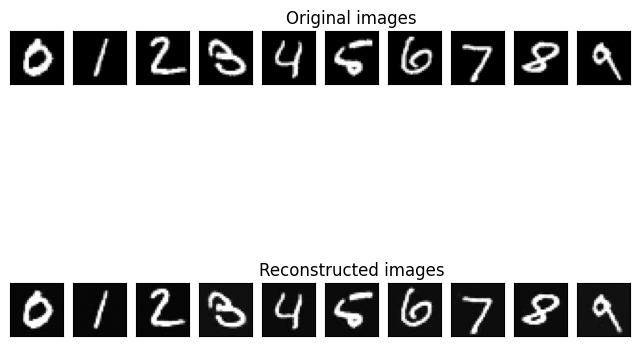


 EPOCH 2/3 	 train loss 0.006073573138564825 	 val loss 0.00342657882720232


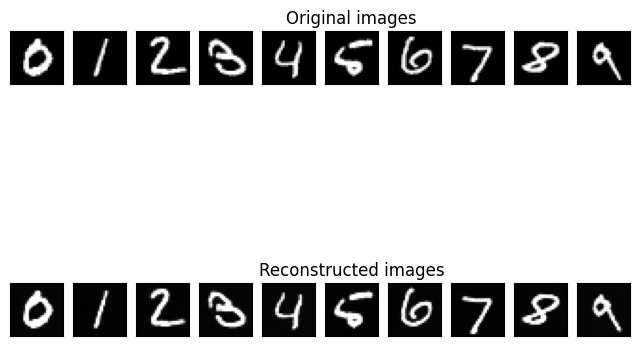


 EPOCH 3/3 	 train loss 0.0030717758927494287 	 val loss 0.002022331114858389


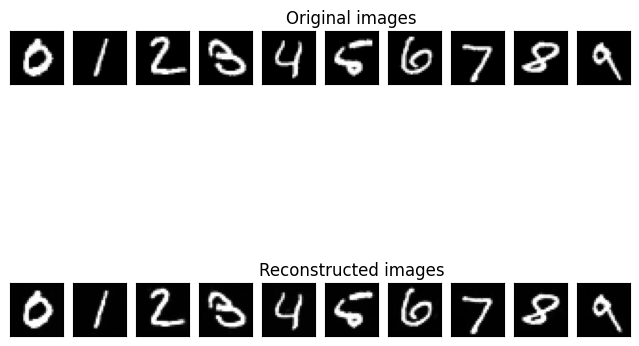

In [21]:
num_epochs = 3
diz_loss = {'train_loss':[],'val_loss':[]}
for epoch in range(num_epochs):
    train_loss =train_epoch(model,device,trainloader,loss_fn,optim)
    val_loss = test_epoch(model,device,testloader,loss_fn)
    print('\n EPOCH {}/{} \t train loss {} \t val loss {}'.format(epoch + 1, num_epochs,train_loss,val_loss))
    diz_loss['train_loss'].append(train_loss)
    diz_loss['val_loss'].append(val_loss)
    plot_ae_outputs(model,n=10)

In [22]:
sample_data = torch.from_numpy(X_test[0]).unsqueeze(0)
model.eval()
pred = model.encoder(sample_data)
print(pred.shape)

torch.Size([1, 576])
